# Phase 1: Dataset Generation
To train our continuous-time RNNs and run the Partial Information Decomposition (PID), we first need to generate the task data. The tasks are based on Mante et al. (2013) and are generated using the NeuroGym framework.

**Generation Options:**
*   **Full Regeneration:** Generates the massive training and validation sets (~160k trials) plus 10 distinct test sets.
*   **Test Sets Only:** If you are using our pre-trained model weights, you can skip the training data generation and only generate the 10 test sets required for the PID analysis.

In [1]:
import os

# --- DATASET GENERATION CONFIGURATION ---
# Set to True to regenerate training and validation sets (takes ~300MB of disk space)
# Set to False to ONLY generate the 10 Test Sets (recommended if using pre-trained weights)
REGENERATE_TRAIN_VAL = False
N_TEST_SETS = 10
BASE_PATH = '../data'

# Construct the arguments based on user preference
train_val_args = "" if REGENERATE_TRAIN_VAL else "--n_train 0 --n_val 0"

# Note: Assumes the notebook is run from the project root. 
# If running inside the 'notebooks/' folder, use '!python ../src/tasks/data_generator.py ...'
!python ../src/tasks/data_generator.py --mode perceptual {train_val_args} --n_test_sets {N_TEST_SETS} --output_dir {BASE_PATH}

!python ../src/tasks/data_generator.py --mode context {train_val_args} --n_test_sets {N_TEST_SETS} --output_dir {BASE_PATH}

=== Generating PERCEPTUAL Dataset ===

Generating 10 distinct Test Sets...

Processing Split: test_01 (2000 trials | Explicit Seed: 1)
  Saved to ../data\perceptual\test_01.npz (1.3 MB)

Processing Split: test_02 (2000 trials | Explicit Seed: 2)
  Saved to ../data\perceptual\test_02.npz (1.3 MB)

Processing Split: test_03 (2000 trials | Explicit Seed: 3)
  Saved to ../data\perceptual\test_03.npz (1.3 MB)

Processing Split: test_04 (2000 trials | Explicit Seed: 4)
  Saved to ../data\perceptual\test_04.npz (1.3 MB)

Processing Split: test_05 (2000 trials | Explicit Seed: 5)
  Saved to ../data\perceptual\test_05.npz (1.3 MB)

Processing Split: test_06 (2000 trials | Explicit Seed: 6)
  Saved to ../data\perceptual\test_06.npz (1.3 MB)

Processing Split: test_07 (2000 trials | Explicit Seed: 7)
  Saved to ../data\perceptual\test_07.npz (1.3 MB)

Processing Split: test_08 (2000 trials | Explicit Seed: 8)
  Saved to ../data\perceptual\test_08.npz (1.3 MB)

Processing Split: test_09 (2000 tria

c:\Users\sinde\anaconda3\envs\neuroai-project13\Lib\site-packages\gymnasium\envs\registration.py:481: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['paper_link', 'paper_name', 'tags']
  logger.warn(
c:\Users\sinde\anaconda3\envs\neuroai-project13\Lib\site-packages\gymnasium\core.py:311: UserWarning: WARN: env.seed to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.seed` for environment variables or `env.get_wrapper_attr('seed')` that will search the reminding wrappers.
  logger.warn(
c:\Users\sinde\anaconda3\envs\neuroai-project13\Lib\site-packages\gymnasium\core.py:311: UserWarning: WARN: env.new_trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.new_trial` for environment variables or `env.get_wrapper_attr('new_trial')` that will search the reminding wrappers.
  logger.warn(


=== Generating CONTEXT Dataset ===

Generating 10 distinct Test Sets...

Processing Split: test_01 (2000 trials | Explicit Seed: 1)
  Saved to ../data\context\test_01.npz (2.4 MB)

Processing Split: test_02 (2000 trials | Explicit Seed: 2)
  Saved to ../data\context\test_02.npz (2.4 MB)

Processing Split: test_03 (2000 trials | Explicit Seed: 3)
  Saved to ../data\context\test_03.npz (2.4 MB)

Processing Split: test_04 (2000 trials | Explicit Seed: 4)
  Saved to ../data\context\test_04.npz (2.4 MB)

Processing Split: test_05 (2000 trials | Explicit Seed: 5)
  Saved to ../data\context\test_05.npz (2.4 MB)

Processing Split: test_06 (2000 trials | Explicit Seed: 6)
  Saved to ../data\context\test_06.npz (2.4 MB)

Processing Split: test_07 (2000 trials | Explicit Seed: 7)
  Saved to ../data\context\test_07.npz (2.4 MB)

Processing Split: test_08 (2000 trials | Explicit Seed: 8)
  Saved to ../data\context\test_08.npz (2.4 MB)

Processing Split: test_09 (2000 trials | Explicit Seed: 9)
  Sa

c:\Users\sinde\anaconda3\envs\neuroai-project13\Lib\site-packages\gymnasium\envs\registration.py:481: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['paper_link', 'paper_name', 'tags']
  logger.warn(
c:\Users\sinde\anaconda3\envs\neuroai-project13\Lib\site-packages\gymnasium\core.py:311: UserWarning: WARN: env.seed to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.seed` for environment variables or `env.get_wrapper_attr('seed')` that will search the reminding wrappers.
  logger.warn(
c:\Users\sinde\anaconda3\envs\neuroai-project13\Lib\site-packages\gymnasium\core.py:311: UserWarning: WARN: env.new_trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.new_trial` for environment variables or `env.get_wrapper_attr('new_trial')` that will search the reminding wrappers.
  logger.warn(


# Phase 2: The NeuroGym Data Tour
Before we train the RNN, let's inspect the data we just generated. NeuroGym generates cognitive tasks with specific temporal phases:
1. **Fixation:** The network must output a 'fixation' action (usually class 0) and wait.
2. **Stimulus:** The noisy evidence is presented. The network must continue to fixate while internally accumulating evidence.
3. **Decision:** The stimulus turns off, and the network must output its choice based on the accumulated evidence.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.tasks.data_loader import load_mante_data

BASE_PATH = '../data'

print("Loading newly generated test datasets...")
context_loader = load_mante_data(f'{BASE_PATH}/context/test_01.npz', batch_size=1, shuffle=True, subsample_step=1)
perceptual_loader = load_mante_data(f'{BASE_PATH}/perceptual/test_01.npz', batch_size=1, shuffle=True, subsample_step=1)

# Pull one single trial from each
ctx_obs, ctx_labels, ctx_periods, ctx_coh, ctx_ctx = next(iter(context_loader))
per_obs, per_labels, per_periods, per_coh, per_ctx = next(iter(perceptual_loader))

# Remove batch dimension for plotting: shape becomes (Timesteps, Features)
ctx_obs = ctx_obs.squeeze(0).numpy()
ctx_labels = ctx_labels.squeeze(0).numpy()

per_obs = per_obs.squeeze(0).numpy()
per_labels = per_labels.squeeze(0).numpy()

print("Data loaded successfully!")

Loading newly generated test datasets...
Data loaded successfully!


### Visualizing Perceptual Decision Making (Low Integration)
In this task, the network receives a single stream of noisy evidence (e.g., dots moving left or right). Notice how the target changes from `0` (Fixate) to the correct choice (e.g., `1` or `2`) at the very end of the trial.

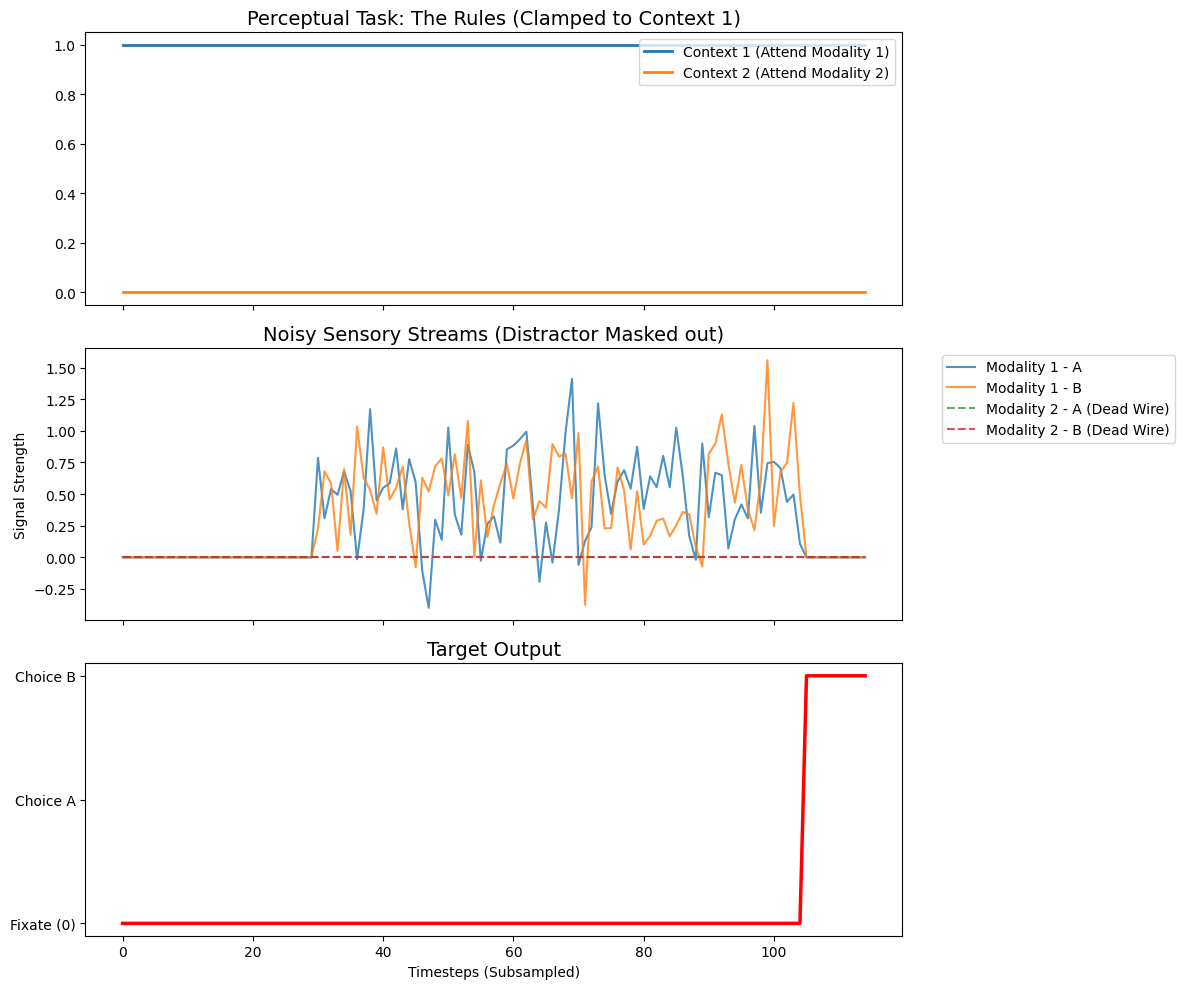

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Plot the Rules (Context Cues) - Notice how it is Clamped!
axes[0].plot(per_obs[:, 5], label="Context 1 (Attend Modality 1)", color="#1f77b4", linewidth=2)
axes[0].plot(per_obs[:, 6], label="Context 2 (Attend Modality 2)", color="#ff7f0e", linewidth=2)
axes[0].set_title("Perceptual Task: The Rules (Clamped to Context 1)", fontsize=14)
axes[0].legend(loc="upper right")

# 2. Plot the Noisy Sensory Streams - Notice how Distractor is Dead!
axes[1].plot(per_obs[:, 1], label="Modality 1 - A", color="#1f77b4", alpha=0.8)
axes[1].plot(per_obs[:, 2], label="Modality 1 - B", color="#ff7f0e", alpha=0.8)
axes[1].plot(per_obs[:, 3], label="Modality 2 - A (Dead Wire)", color="#2ca02c", linestyle='--', alpha=0.8)
axes[1].plot(per_obs[:, 4], label="Modality 2 - B (Dead Wire)", color="#d62728", linestyle='--', alpha=0.8)
axes[1].set_title("Noisy Sensory Streams (Distractor Masked out)", fontsize=14)
axes[1].set_ylabel("Signal Strength")
axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")

# 3. Plot the Target Output
axes[2].plot(per_labels, color="red", linewidth=2.5, label="Target Output")
axes[2].set_title("Target Output", fontsize=14)
axes[2].set_yticks([0, 1, 2])
axes[2].set_yticklabels(["Fixate (0)", "Choice A", "Choice B"])
axes[2].set_xlabel("Timesteps (Subsampled)")

plt.tight_layout()
plt.show()

### Visualizing Context Decision Making (High Integration)
This is where synergy is expected to emerge! The network now receives **four** noisy stimulus channels (e.g., Motion Left, Motion Right, Color Red, Color Blue) AND **two** context channels. The network must use the context channel to figure out which pair of stimulus channels to pay attention to, and actively ignore the other pair.

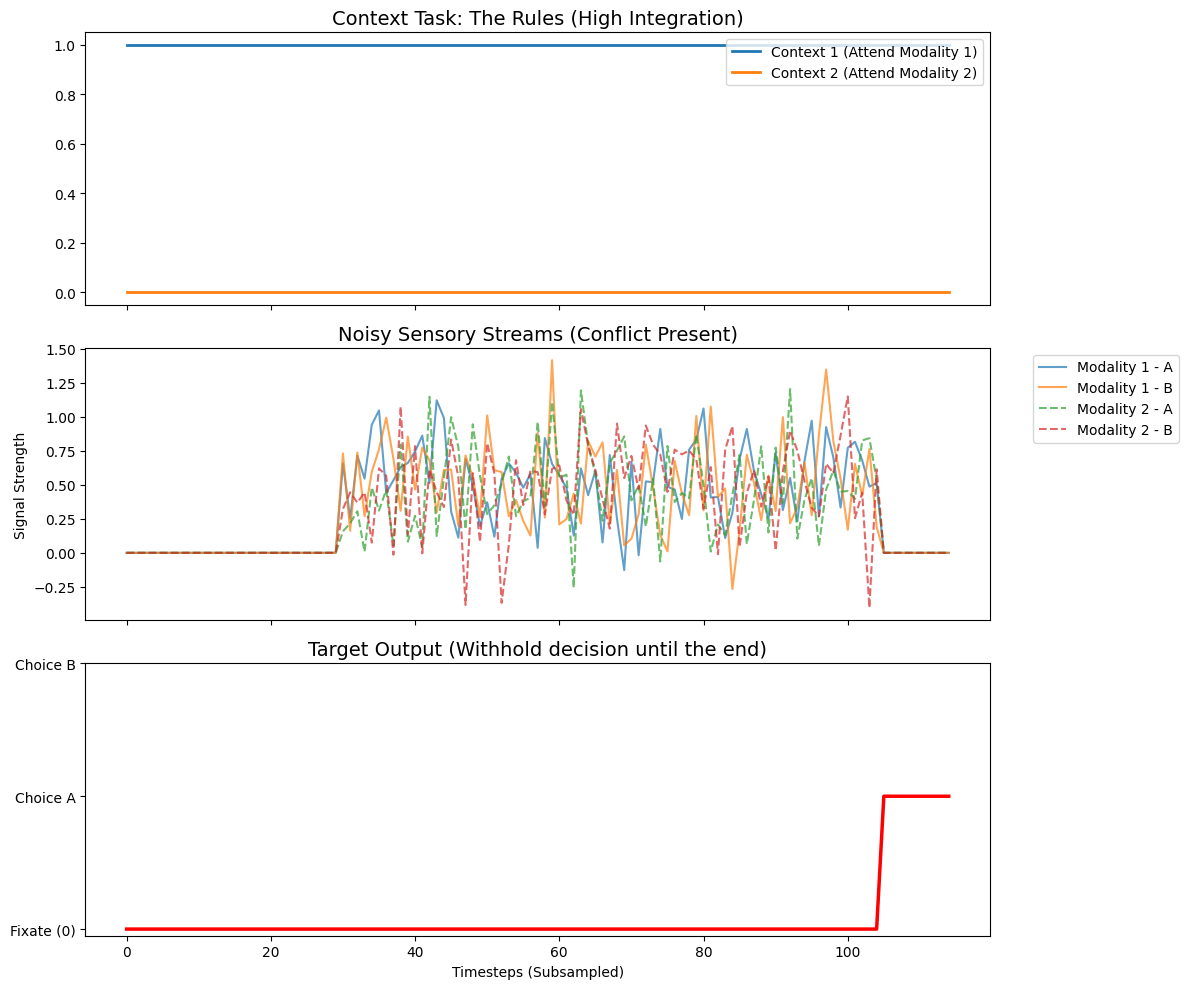

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Plot the Rules (Context Cues)
axes[0].plot(ctx_obs[:, 5], label="Context 1 (Attend Modality 1)", color="#1f77b4", linewidth=2)
axes[0].plot(ctx_obs[:, 6], label="Context 2 (Attend Modality 2)", color="#ff7f0e", linewidth=2)
axes[0].set_title("Context Task: The Rules (High Integration)", fontsize=14)
axes[0].legend(loc="upper right")

# 2. Plot the Noisy Sensory Streams (Both are active!)
axes[1].plot(ctx_obs[:, 1], label="Modality 1 - A", color="#1f77b4", alpha=0.7)
axes[1].plot(ctx_obs[:, 2], label="Modality 1 - B", color="#ff7f0e", alpha=0.7)
axes[1].plot(ctx_obs[:, 3], label="Modality 2 - A", color="#2ca02c", linestyle='--', alpha=0.7)
axes[1].plot(ctx_obs[:, 4], label="Modality 2 - B", color="#d62728", linestyle='--', alpha=0.7)
axes[1].set_title("Noisy Sensory Streams (Conflict Present)", fontsize=14)
axes[1].set_ylabel("Signal Strength")
axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")

# 3. Plot the Target Output
axes[2].plot(ctx_labels, color="red", linewidth=2.5, label="Target Output")
axes[2].set_title("Target Output (Withhold decision until the end)", fontsize=14)
axes[2].set_yticks([0, 1, 2])
axes[2].set_yticklabels(["Fixate (0)", "Choice A", "Choice B"])
axes[2].set_xlabel("Timesteps (Subsampled)")

plt.tight_layout()
plt.show()